In [2]:
!pip install -q ultralytics scikit-learn grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 80.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 require

In [3]:
import gc
import random
import shutil
import time
import warnings

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from ultralytics import YOLO

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)

from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
SEEDS = [0, 42, 123]

EPOCHS = 50
IMAGE_SIZE = 224
BATCH_SIZE = 32
WORKERS = 2

DEVICE = 0 if torch.cuda.is_available() else "cpu"

OUTPUT_ROOT = Path("/kaggle/working/brain_tumor_yolov8")

DATASET_DIR = OUTPUT_ROOT / "fixed_dataset"
RUNS_DIR = OUTPUT_ROOT / "runs"
RESULTS_DIR = OUTPUT_ROOT / "results"
GRADCAM_DIR = OUTPUT_ROOT / "gradcam"

for folder in [
    OUTPUT_ROOT,
    RUNS_DIR,
    RESULTS_DIR,
    GRADCAM_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Output folder:", OUTPUT_ROOT)

Device: 0
Output folder: /kaggle/working/brain_tumor_yolov8


In [5]:
INPUT_ROOT = Path("/kaggle/input")

training_candidates = [
    path
    for path in INPUT_ROOT.rglob("Training")
    if path.is_dir()
]

testing_candidates = [
    path
    for path in INPUT_ROOT.rglob("Testing")
    if path.is_dir()
]

print("Training folders found:")
for path in training_candidates:
    print(path)

print("\nTesting folders found:")
for path in testing_candidates:
    print(path)

if not training_candidates:
    raise FileNotFoundError(
        "No Training folder found. Add the Brain Tumor MRI Dataset "
        "to the Kaggle notebook input."
    )

if not testing_candidates:
    raise FileNotFoundError(
        "No Testing folder found. Add the Brain Tumor MRI Dataset "
        "to the Kaggle notebook input."
    )

TRAIN_SOURCE = training_candidates[0]
TEST_SOURCE = testing_candidates[0]

print("\nSelected Training folder:", TRAIN_SOURCE)
print("Selected Testing folder :", TEST_SOURCE)

Training folders found:
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training

Testing folders found:
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing

Selected Training folder: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Selected Testing folder : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing


In [6]:
VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}


def get_image_files(folder):
    folder = Path(folder)

    return sorted([
        path
        for path in folder.iterdir()
        if path.is_file()
        and path.suffix.lower() in VALID_EXTENSIONS
    ])


def get_class_counts(source_folder):
    counts = {}

    for class_folder in sorted(Path(source_folder).iterdir()):
        if class_folder.is_dir():
            counts[class_folder.name] = len(
                get_image_files(class_folder)
            )

    return counts


training_source_counts = get_class_counts(TRAIN_SOURCE)
testing_source_counts = get_class_counts(TEST_SOURCE)

print("Training folder:", TRAIN_SOURCE)
print("Testing folder :", TEST_SOURCE)

print("\nOriginal Training counts:")
print(training_source_counts)
print("Training total:", sum(training_source_counts.values()))

print("\nOriginal Testing counts:")
print(testing_source_counts)
print("Testing total:", sum(testing_source_counts.values()))

Training folder: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Testing folder : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing

Original Training counts:
{'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
Training total: 5600

Original Testing counts:
{'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}
Testing total: 1600


In [7]:
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

for split_name in ["train", "val", "test"]:
    (DATASET_DIR / split_name).mkdir(
        parents=True,
        exist_ok=True,
    )

SPLIT_SEED = 123
VALIDATION_RATIO = 0.20

random.seed(SPLIT_SEED)


def copy_files(file_paths, destination):
    destination.mkdir(
        parents=True,
        exist_ok=True,
    )

    for source_path in file_paths:
        shutil.copy2(
            source_path,
            destination / source_path.name,
        )


training_classes = sorted([
    path.name
    for path in TRAIN_SOURCE.iterdir()
    if path.is_dir()
])

for class_name in training_classes:
    class_files = get_image_files(
        TRAIN_SOURCE / class_name
    )

    random.shuffle(class_files)

    number_validation = int(
        len(class_files) * VALIDATION_RATIO
    )

    validation_files = class_files[:number_validation]
    training_files = class_files[number_validation:]

    copy_files(
        training_files,
        DATASET_DIR / "train" / class_name,
    )

    copy_files(
        validation_files,
        DATASET_DIR / "val" / class_name,
    )


testing_classes = sorted([
    path.name
    for path in TEST_SOURCE.iterdir()
    if path.is_dir()
])

for class_name in testing_classes:
    testing_files = get_image_files(
        TEST_SOURCE / class_name
    )

    copy_files(
        testing_files,
        DATASET_DIR / "test" / class_name,
    )

print("Fixed dataset created at:", DATASET_DIR)

Fixed dataset created at: /kaggle/working/brain_tumor_yolov8/fixed_dataset


In [8]:
def count_split(split_name):
    split_path = DATASET_DIR / split_name
    counts = {}

    for class_folder in sorted(split_path.iterdir()):
        if class_folder.is_dir():
            counts[class_folder.name] = len(
                get_image_files(class_folder)
            )

    return counts


split_counts = {}

for split_name in ["train", "val", "test"]:
    counts = count_split(split_name)
    split_counts[split_name] = counts

    print(f"\n{split_name.upper()}:")
    print(counts)
    print("Total:", sum(counts.values()))


TRAIN:
{'glioma': 1120, 'meningioma': 1120, 'notumor': 1120, 'pituitary': 1120}
Total: 4480

VAL:
{'glioma': 280, 'meningioma': 280, 'notumor': 280, 'pituitary': 280}
Total: 1120

TEST:
{'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}
Total: 1600


In [9]:
EXPECTED_TOTALS = {
    "train": 4480,
    "val": 1120,
    "test": 1600,
}

for split_name, expected_total in EXPECTED_TOTALS.items():
    actual_total = sum(split_counts[split_name].values())

    assert actual_total == expected_total, (
        f"{split_name}: expected {expected_total}, "
        f"but found {actual_total}"
    )


manifest_records = []

for split_name in ["train", "val", "test"]:
    split_path = DATASET_DIR / split_name

    for class_folder in sorted(split_path.iterdir()):
        if not class_folder.is_dir():
            continue

        for image_path in get_image_files(class_folder):
            manifest_records.append(
                {
                    "split": split_name,
                    "class_name": class_folder.name,
                    "filename": image_path.name,
                    "filepath": str(image_path),
                }
            )


manifest_df = pd.DataFrame(manifest_records)

manifest_path = (
    RESULTS_DIR / "fixed_dataset_manifest.csv"
)

manifest_df.to_csv(
    manifest_path,
    index=False,
)

display(
    manifest_df
    .groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
)

print("Dataset verified.")
print("Manifest saved at:", manifest_path)

class_name,glioma,meningioma,notumor,pituitary
split,,,,
test,400,400,400,400
train,1120,1120,1120,1120
val,280,280,280,280


Dataset verified.
Manifest saved at: /kaggle/working/brain_tumor_yolov8/results/fixed_dataset_manifest.csv


In [10]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def clear_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print("Helper functions ready.")

Helper functions ready.


In [11]:
def train_yolov8(seed, augmentation_mode):
    set_all_seeds(seed)
    clear_memory()

    if augmentation_mode == "default":
        run_prefix = "yolov8n_default"

    elif augmentation_mode == "mri":
        run_prefix = "yolov8n_mri_aug"

    else:
        raise ValueError(
            "augmentation_mode must be 'default' or 'mri'"
        )

    run_name = f"{run_prefix}_seed{seed}"

    run_directory = RUNS_DIR / run_name

    best_checkpoint = (
        run_directory
        / "weights"
        / "best.pt"
    )

    last_checkpoint = (
        run_directory
        / "weights"
        / "last.pt"
    )

    if best_checkpoint.exists():
        print(f"✅ Completed checkpoint already exists: {run_name}")
        return str(best_checkpoint)

    print("\n" + "=" * 90)
    print("Run:", run_name)
    print("Seed:", seed)
    print("Augmentation:", augmentation_mode)
    print("=" * 90)

    if last_checkpoint.exists():
        print("🔄 Resuming from:", last_checkpoint)

        model = YOLO(str(last_checkpoint))
        model.train(resume=True)

    else:
        if run_directory.exists():
            shutil.rmtree(run_directory)

        model = YOLO("yolov8n-cls.pt")

        common_arguments = {
            "data": str(DATASET_DIR),
            "epochs": EPOCHS,
            "imgsz": IMAGE_SIZE,
            "batch": BATCH_SIZE,
            "workers": WORKERS,
            "seed": seed,
            "deterministic": True,
            "pretrained": True,
            "optimizer": "auto",
            "device": DEVICE,
            "save": True,
            "save_period": 5,
            "plots": True,
            "project": str(RUNS_DIR),
            "name": run_name,
            "exist_ok": False,
        }

        if augmentation_mode == "default":
            model.train(**common_arguments)

        else:
            model.train(
                **common_arguments,
                auto_augment=None,
                hsv_h=0.0,
                hsv_s=0.0,
                hsv_v=0.10,
                degrees=5.0,
                translate=0.05,
                scale=0.10,
                fliplr=0.5,
                flipud=0.0,
                erasing=0.10,
                mixup=0.0,
                cutmix=0.0,
            )

    if not best_checkpoint.exists():
        raise FileNotFoundError(
            f"Training ended but best.pt was not found: {best_checkpoint}"
        )

    print("✅ Best checkpoint:", best_checkpoint)

    clear_memory()

    return str(best_checkpoint)


print("Training function ready.")

Training function ready.


In [12]:
v8_default_seed0 = train_yolov8(
    seed=0,
    augmentation_mode="default",
)


Run: yolov8n_default_seed0
Seed: 0
Augmentation: default
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brain_tumor_yolov8/fixed_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_default_seed0, n

In [13]:
v8_default_seed42 = train_yolov8(
    seed=42,
    augmentation_mode="default",
)


Run: yolov8n_default_seed42
Seed: 42
Augmentation: default
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brain_tumor_yolov8/fixed_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_default_seed42

In [14]:
v8_default_seed123 = train_yolov8(
    seed=123,
    augmentation_mode="default",
)


Run: yolov8n_default_seed123
Seed: 123
Augmentation: default
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brain_tumor_yolov8/fixed_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_default_seed

In [15]:
v8_mri_seed0 = train_yolov8(
    seed=0,
    augmentation_mode="mri",
)


Run: yolov8n_mri_aug_seed0
Seed: 0
Augmentation: mri
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brain_tumor_yolov8/fixed_dataset, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.1, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_mri_aug_seed0, nbs=64, nms=Fa

In [16]:
v8_mri_seed42 = train_yolov8(
    seed=42,
    augmentation_mode="mri",
)


Run: yolov8n_mri_aug_seed42
Seed: 42
Augmentation: mri
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brain_tumor_yolov8/fixed_dataset, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.1, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_mri_aug_seed42, nbs=64, nms

In [17]:
v8_mri_seed123 = train_yolov8(
    seed=123,
    augmentation_mode="mri",
)


Run: yolov8n_mri_aug_seed123
Seed: 123
Augmentation: mri
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brain_tumor_yolov8/fixed_dataset, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.1, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_mri_aug_seed123, nbs=64, 

In [18]:
all_checkpoints = {
    "default_seed0": Path(v8_default_seed0),
    "default_seed42": Path(v8_default_seed42),
    "default_seed123": Path(v8_default_seed123),
    "mri_seed0": Path(v8_mri_seed0),
    "mri_seed42": Path(v8_mri_seed42),
    "mri_seed123": Path(v8_mri_seed123),
}

for run_name, checkpoint_path in all_checkpoints.items():
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Missing checkpoint for {run_name}: {checkpoint_path}"
        )

    print(f"✅ {run_name}: {checkpoint_path}")

print("\nAll six checkpoints are available.")

✅ default_seed0: /kaggle/working/brain_tumor_yolov8/runs/yolov8n_default_seed0/weights/best.pt
✅ default_seed42: /kaggle/working/brain_tumor_yolov8/runs/yolov8n_default_seed42/weights/best.pt
✅ default_seed123: /kaggle/working/brain_tumor_yolov8/runs/yolov8n_default_seed123/weights/best.pt
✅ mri_seed0: /kaggle/working/brain_tumor_yolov8/runs/yolov8n_mri_aug_seed0/weights/best.pt
✅ mri_seed42: /kaggle/working/brain_tumor_yolov8/runs/yolov8n_mri_aug_seed42/weights/best.pt
✅ mri_seed123: /kaggle/working/brain_tumor_yolov8/runs/yolov8n_mri_aug_seed123/weights/best.pt

All six checkpoints are available.


In [19]:
# =========================
# CELL 18 — EVALUATION HELPER FUNCTION
# =========================

def evaluate_classifier(checkpoint_path, split_name, run_name):
    clear_memory()

    model = YOLO(str(checkpoint_path))

    split_path = DATASET_DIR / split_name

    results = model.predict(
        source=str(split_path),
        imgsz=IMAGE_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        workers=WORKERS,
        verbose=False,
        stream=False,
    )

    y_true = []
    y_pred = []
    y_prob = []
    image_paths = []

    class_to_index = {
        class_name: index
        for index, class_name in enumerate(CLASS_NAMES)
    }

    for result in results:
        image_path = Path(result.path)
        true_class_name = image_path.parent.name

        probabilities = (
            result.probs.data
            .detach()
            .cpu()
            .numpy()
        )

        predicted_index = int(np.argmax(probabilities))
        true_index = class_to_index[true_class_name]

        y_true.append(true_index)
        y_pred.append(predicted_index)
        y_prob.append(probabilities)
        image_paths.append(str(image_path))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    y_true_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    try:
        macro_roc_auc = roc_auc_score(
            y_true_binary,
            y_prob,
            average="macro",
            multi_class="ovr",
        )
    except ValueError:
        macro_roc_auc = np.nan

    try:
        macro_average_precision = average_precision_score(
            y_true_binary,
            y_prob,
            average="macro",
        )
    except ValueError:
        macro_average_precision = np.nan

    metrics = {
        "run_name": run_name,
        "split": split_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "mcc": mcc,
        "macro_roc_auc": macro_roc_auc,
        "macro_average_precision": macro_average_precision,
    }

    predictions_df = pd.DataFrame({
        "image_path": image_paths,
        "true_index": y_true,
        "predicted_index": y_pred,
        "true_class": [CLASS_NAMES[index] for index in y_true],
        "predicted_class": [CLASS_NAMES[index] for index in y_pred],
    })

    for class_index, class_name in enumerate(CLASS_NAMES):
        predictions_df[f"prob_{class_name}"] = y_prob[:, class_index]

    print(f"{run_name} | {split_name}")
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Balanced Accuracy : {balanced_accuracy:.4f}")
    print(f"Macro Precision   : {precision:.4f}")
    print(f"Macro Recall      : {recall:.4f}")
    print(f"Macro F1          : {f1:.4f}")
    print(f"MCC               : {mcc:.4f}")
    print(f"Macro ROC-AUC     : {macro_roc_auc:.4f}")
    print(f"Macro AP          : {macro_average_precision:.4f}")

    clear_memory()

    return metrics, predictions_df


print("Evaluation function ready.")

Evaluation function ready.


In [21]:
# =========================
# CORRECTED CELL 18 — EVALUATION HELPER
# =========================

def evaluate_classifier(checkpoint_path, split_name, run_name):
    clear_memory()

    model = YOLO(str(checkpoint_path))
    split_path = DATASET_DIR / split_name

    image_paths = sorted([
        str(path)
        for path in split_path.rglob("*")
        if path.is_file()
        and path.suffix.lower() in VALID_EXTENSIONS
    ])

    if not image_paths:
        raise FileNotFoundError(
            f"No images found recursively inside: {split_path}"
        )

    print(f"Found {len(image_paths)} images in {split_name}")

    results = model.predict(
        source=image_paths,
        imgsz=IMAGE_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        verbose=False,
        stream=False,
    )

    y_true = []
    y_pred = []
    y_prob = []
    processed_paths = []

    class_to_index = {
        class_name: index
        for index, class_name in enumerate(CLASS_NAMES)
    }

    for result in results:
        image_path = Path(result.path)
        true_class_name = image_path.parent.name

        probabilities = (
            result.probs.data
            .detach()
            .cpu()
            .numpy()
        )

        predicted_index = int(np.argmax(probabilities))
        true_index = class_to_index[true_class_name]

        y_true.append(true_index)
        y_pred.append(predicted_index)
        y_prob.append(probabilities)
        processed_paths.append(str(image_path))

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    y_true_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    try:
        macro_roc_auc = roc_auc_score(
            y_true_binary,
            y_prob,
            average="macro",
            multi_class="ovr",
        )
    except ValueError:
        macro_roc_auc = np.nan

    try:
        macro_average_precision = average_precision_score(
            y_true_binary,
            y_prob,
            average="macro",
        )
    except ValueError:
        macro_average_precision = np.nan

    metrics = {
        "run_name": run_name,
        "split": split_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "mcc": mcc,
        "macro_roc_auc": macro_roc_auc,
        "macro_average_precision": macro_average_precision,
    }

    predictions_df = pd.DataFrame({
        "image_path": processed_paths,
        "true_index": y_true,
        "predicted_index": y_pred,
        "true_class": [CLASS_NAMES[i] for i in y_true],
        "predicted_class": [CLASS_NAMES[i] for i in y_pred],
    })

    for class_index, class_name in enumerate(CLASS_NAMES):
        predictions_df[f"prob_{class_name}"] = y_prob[:, class_index]

    print(f"\n{run_name} | {split_name}")
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Balanced Accuracy : {balanced_accuracy:.4f}")
    print(f"Macro Precision   : {precision:.4f}")
    print(f"Macro Recall      : {recall:.4f}")
    print(f"Macro F1          : {f1:.4f}")
    print(f"MCC               : {mcc:.4f}")
    print(f"Macro ROC-AUC     : {macro_roc_auc:.4f}")
    print(f"Macro AP          : {macro_average_precision:.4f}")

    clear_memory()

    return metrics, predictions_df


print("Corrected evaluation function ready.")

Corrected evaluation function ready.


In [23]:
# =========================
# CELL 19 — EVALUATE ALL SIX MODELS
# =========================

CLASS_NAMES = sorted([
    folder.name
    for folder in (DATASET_DIR / "train").iterdir()
    if folder.is_dir()
])

all_metrics = []
all_predictions = {}

for run_name, checkpoint_path in all_checkpoints.items():
    for split_name in ["val", "test"]:
        print("\n" + "=" * 90)

        metrics, predictions_df = evaluate_classifier(
            checkpoint_path=checkpoint_path,
            split_name=split_name,
            run_name=run_name,
        )

        all_metrics.append(metrics)

        prediction_key = f"{run_name}_{split_name}"
        all_predictions[prediction_key] = predictions_df

        predictions_df.to_csv(
            RESULTS_DIR / f"{prediction_key}_predictions.csv",
            index=False,
        )

metrics_df = pd.DataFrame(all_metrics)

metrics_path = RESULTS_DIR / "all_model_metrics.csv"

metrics_df.to_csv(
    metrics_path,
    index=False,
)

display(
    metrics_df.sort_values(
        by=["split", "macro_f1"],
        ascending=[True, False],
    ).reset_index(drop=True)
)

print("\nMetrics saved at:", metrics_path)


Found 1120 images in val

default_seed0 | val
Accuracy          : 0.9839
Balanced Accuracy : 0.9839
Macro Precision   : 0.9839
Macro Recall      : 0.9839
Macro F1          : 0.9839
MCC               : 0.9786
Macro ROC-AUC     : 0.9992
Macro AP          : 0.9979

Found 1600 images in test

default_seed0 | test
Accuracy          : 0.9519
Balanced Accuracy : 0.9519
Macro Precision   : 0.9543
Macro Recall      : 0.9519
Macro F1          : 0.9508
MCC               : 0.9372
Macro ROC-AUC     : 0.9915
Macro AP          : 0.9831

Found 1120 images in val

default_seed42 | val
Accuracy          : 0.9875
Balanced Accuracy : 0.9875
Macro Precision   : 0.9875
Macro Recall      : 0.9875
Macro F1          : 0.9875
MCC               : 0.9833
Macro ROC-AUC     : 0.9994
Macro AP          : 0.9985

Found 1600 images in test

default_seed42 | test
Accuracy          : 0.9563
Balanced Accuracy : 0.9563
Macro Precision   : 0.9586
Macro Recall      : 0.9563
Macro F1          : 0.9555
MCC               : 0.9

,run_name,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,mcc,macro_roc_auc,macro_average_precision
0,default_seed42,test,0.956250,0.956250,0.958628,0.956250,0.955545,0.942847,0.991337,0.983800
1,default_seed123,test,0.955625,0.955625,0.957611,0.955625,0.954715,0.942010,0.992482,0.985739
2,default_seed0,test,0.951875,0.951875,0.954299,0.951875,0.950830,0.937220,0.991538,0.983063
3,mri_seed123,test,0.950625,0.950625,0.954378,0.950625,0.949422,0.936048,0.991223,0.982056
4,mri_seed0,test,0.950000,0.950000,0.954269,0.950000,0.948925,0.935354,0.988356,0.978550
5,mri_seed42,test,0.948750,0.948750,0.952926,0.948750,0.947359,0.933771,0.990086,0.980679
6,mri_seed42,val,0.989286,0.989286,0.989276,0.989286,0.989279,0.985715,0.999408,0.998453
7,mri_seed0,val,0.987500,0.987500,0.987538,0.987500,0.987503,0.983344,0.998720,0.996968
8,default_seed42,val,0.987500,0.987500,0.987506,0.987500,0.987494,0.983340,0.999447,0.998468
9,default_seed123,val,0.986607,0.986607,0.986620,0.986607,0.986609,0.982146,0.999363,0.998270



Metrics saved at: /kaggle/working/brain_tumor_yolov8/results/all_model_metrics.csv


In [24]:
# =========================
# CELL 21 — SELECT BEST MODEL
# =========================

validation_results = metrics_df[
    metrics_df["split"] == "val"
].copy()

best_validation_row = validation_results.loc[
    validation_results["macro_f1"].idxmax()
]

BEST_RUN_NAME = best_validation_row["run_name"]
BEST_CHECKPOINT = all_checkpoints[BEST_RUN_NAME]

print("Best run selected using validation Macro-F1")
print("-" * 60)
print("Run name            :", BEST_RUN_NAME)
print("Checkpoint          :", BEST_CHECKPOINT)
print("Validation Accuracy :", f"{best_validation_row['accuracy']:.4f}")
print("Validation Macro-F1 :", f"{best_validation_row['macro_f1']:.4f}")
print("Validation MCC      :", f"{best_validation_row['mcc']:.4f}")
print("Validation ROC-AUC  :", f"{best_validation_row['macro_roc_auc']:.4f}")

best_model_summary = pd.DataFrame([
    {
        "best_run_name": BEST_RUN_NAME,
        "checkpoint": str(BEST_CHECKPOINT),
        "selection_split": "val",
        "selection_metric": "macro_f1",
        "validation_accuracy": best_validation_row["accuracy"],
        "validation_macro_f1": best_validation_row["macro_f1"],
        "validation_mcc": best_validation_row["mcc"],
        "validation_macro_roc_auc": best_validation_row["macro_roc_auc"],
    }
])

best_model_summary_path = (
    RESULTS_DIR / "best_model_selection.csv"
)

best_model_summary.to_csv(
    best_model_summary_path,
    index=False,
)

print("\nBest model summary saved at:", best_model_summary_path)

Best run selected using validation Macro-F1
------------------------------------------------------------
Run name            : mri_seed42
Checkpoint          : /kaggle/working/brain_tumor_yolov8/runs/yolov8n_mri_aug_seed42/weights/best.pt
Validation Accuracy : 0.9893
Validation Macro-F1 : 0.9893
Validation MCC      : 0.9857
Validation ROC-AUC  : 0.9994

Best model summary saved at: /kaggle/working/brain_tumor_yolov8/results/best_model_selection.csv


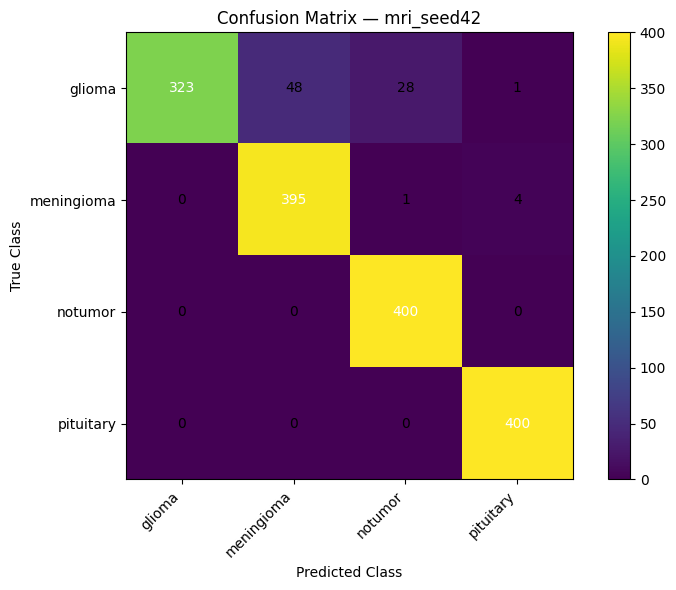

,glioma,meningioma,notumor,pituitary
glioma,323,48,28,1
meningioma,0,395,1,4
notumor,0,0,400,0
pituitary,0,0,0,400


,precision,recall,f1-score,support
glioma,1.000000,0.80750,0.893499,400.00000
meningioma,0.891648,0.98750,0.937129,400.00000
notumor,0.932401,1.00000,0.965018,400.00000
pituitary,0.987654,1.00000,0.993789,400.00000
accuracy,0.948750,0.94875,0.948750,0.94875
macro avg,0.952926,0.94875,0.947359,1600.00000
weighted avg,0.952926,0.94875,0.947359,1600.00000


Confusion matrix saved at: /kaggle/working/brain_tumor_yolov8/results/mri_seed42_test_confusion_matrix.csv
Confusion matrix image saved at: /kaggle/working/brain_tumor_yolov8/results/mri_seed42_test_confusion_matrix.png
Classification report saved at: /kaggle/working/brain_tumor_yolov8/results/mri_seed42_test_classification_report.csv


In [25]:
# =========================
# CELL 22 — BEST MODEL CONFUSION MATRIX AND CLASSIFICATION REPORT
# =========================

best_test_key = f"{BEST_RUN_NAME}_test"

best_test_predictions = all_predictions[
    best_test_key
].copy()

y_true_best = best_test_predictions[
    "true_index"
].to_numpy()

y_pred_best = best_test_predictions[
    "predicted_index"
].to_numpy()

confusion_matrix_values = confusion_matrix(
    y_true_best,
    y_pred_best,
)

confusion_matrix_df = pd.DataFrame(
    confusion_matrix_values,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)

confusion_matrix_path = (
    RESULTS_DIR
    / f"{BEST_RUN_NAME}_test_confusion_matrix.csv"
)

confusion_matrix_df.to_csv(
    confusion_matrix_path
)

plt.figure(figsize=(8, 6))

plt.imshow(
    confusion_matrix_values,
    interpolation="nearest",
)

plt.title(
    f"Confusion Matrix — {BEST_RUN_NAME}"
)

plt.colorbar()

tick_positions = np.arange(
    len(CLASS_NAMES)
)

plt.xticks(
    tick_positions,
    CLASS_NAMES,
    rotation=45,
    ha="right",
)

plt.yticks(
    tick_positions,
    CLASS_NAMES,
)

threshold = (
    confusion_matrix_values.max() / 2
)

for row_index in range(
    confusion_matrix_values.shape[0]
):
    for column_index in range(
        confusion_matrix_values.shape[1]
    ):
        value = confusion_matrix_values[
            row_index,
            column_index,
        ]

        plt.text(
            column_index,
            row_index,
            str(value),
            horizontalalignment="center",
            verticalalignment="center",
            color="white" if value > threshold else "black",
        )

plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()

confusion_matrix_figure_path = (
    RESULTS_DIR
    / f"{BEST_RUN_NAME}_test_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


classification_report_dict = classification_report(
    y_true_best,
    y_pred_best,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

classification_report_df = (
    pd.DataFrame(
        classification_report_dict
    )
    .transpose()
)

classification_report_path = (
    RESULTS_DIR
    / f"{BEST_RUN_NAME}_test_classification_report.csv"
)

classification_report_df.to_csv(
    classification_report_path
)

display(confusion_matrix_df)

display(
    classification_report_df
)

print(
    "Confusion matrix saved at:",
    confusion_matrix_path,
)

print(
    "Confusion matrix image saved at:",
    confusion_matrix_figure_path,
)

print(
    "Classification report saved at:",
    classification_report_path,
)

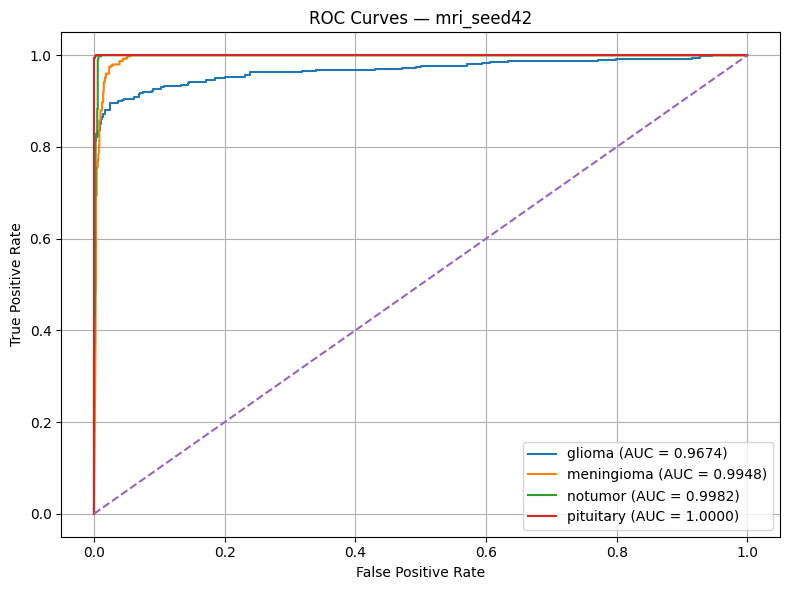

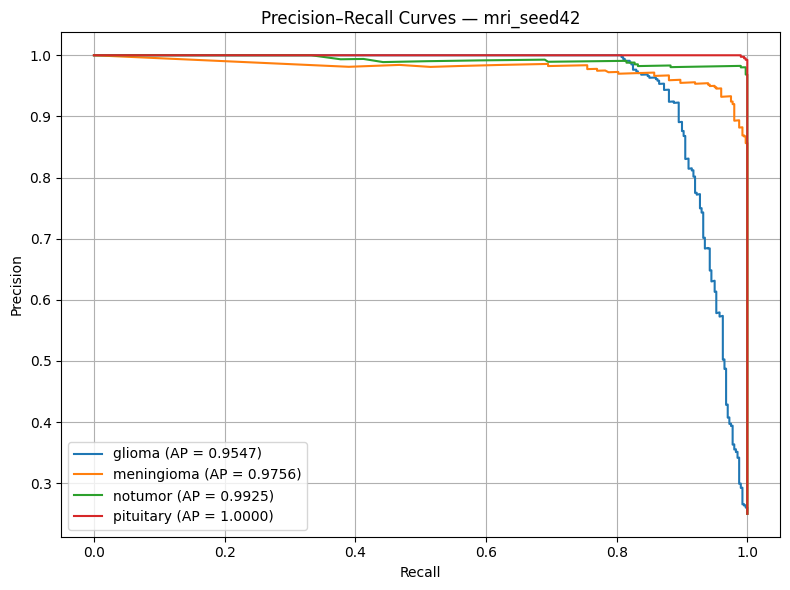

,class_name,roc_auc
0,glioma,0.967433
1,meningioma,0.994751
2,notumor,0.998175
3,pituitary,0.999985


,class_name,average_precision
0,glioma,0.954737
1,meningioma,0.975558
2,notumor,0.992464
3,pituitary,0.999956


ROC curve saved at: /kaggle/working/brain_tumor_yolov8/results/mri_seed42_test_roc_curves.png
Precision–Recall curve saved at: /kaggle/working/brain_tumor_yolov8/results/mri_seed42_test_precision_recall_curves.png


In [26]:
# =========================
# CELL 23 — ROC AND PRECISION-RECALL CURVES
# =========================

probability_columns = [
    f"prob_{class_name}"
    for class_name in CLASS_NAMES
]

y_prob_best = best_test_predictions[
    probability_columns
].to_numpy()

y_true_best_binary = label_binarize(
    y_true_best,
    classes=np.arange(len(CLASS_NAMES)),
)

roc_auc_records = []
pr_auc_records = []


# ROC CURVES
plt.figure(figsize=(8, 6))

for class_index, class_name in enumerate(CLASS_NAMES):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_true_best_binary[:, class_index],
        y_prob_best[:, class_index],
    )

    class_roc_auc = roc_auc_score(
        y_true_best_binary[:, class_index],
        y_prob_best[:, class_index],
    )

    roc_auc_records.append({
        "class_name": class_name,
        "roc_auc": class_roc_auc,
    })

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{class_name} (AUC = {class_roc_auc:.4f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves — {BEST_RUN_NAME}")
plt.legend()
plt.grid(True)
plt.tight_layout()

roc_curve_path = (
    RESULTS_DIR
    / f"{BEST_RUN_NAME}_test_roc_curves.png"
)

plt.savefig(
    roc_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# PRECISION-RECALL CURVES
plt.figure(figsize=(8, 6))

for class_index, class_name in enumerate(CLASS_NAMES):
    precision_values, recall_values, _ = precision_recall_curve(
        y_true_best_binary[:, class_index],
        y_prob_best[:, class_index],
    )

    class_average_precision = average_precision_score(
        y_true_best_binary[:, class_index],
        y_prob_best[:, class_index],
    )

    pr_auc_records.append({
        "class_name": class_name,
        "average_precision": class_average_precision,
    })

    plt.plot(
        recall_values,
        precision_values,
        label=(
            f"{class_name} "
            f"(AP = {class_average_precision:.4f})"
        ),
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Precision–Recall Curves — {BEST_RUN_NAME}"
)
plt.legend()
plt.grid(True)
plt.tight_layout()

pr_curve_path = (
    RESULTS_DIR
    / f"{BEST_RUN_NAME}_test_precision_recall_curves.png"
)

plt.savefig(
    pr_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


roc_auc_df = pd.DataFrame(roc_auc_records)
pr_auc_df = pd.DataFrame(pr_auc_records)

roc_auc_df.to_csv(
    RESULTS_DIR / f"{BEST_RUN_NAME}_per_class_roc_auc.csv",
    index=False,
)

pr_auc_df.to_csv(
    RESULTS_DIR / f"{BEST_RUN_NAME}_per_class_average_precision.csv",
    index=False,
)

display(roc_auc_df)
display(pr_auc_df)

print("ROC curve saved at:", roc_curve_path)
print("Precision–Recall curve saved at:", pr_curve_path)

In [30]:
# =========================
# CORRECTED CELL 24 — PREPARE MODEL FOR GRAD-CAM
# =========================

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import transforms


clear_memory()
torch.set_grad_enabled(True)

gradcam_yolo = YOLO(str(BEST_CHECKPOINT))
gradcam_model = gradcam_yolo.model

gradcam_model.to(DEVICE)
gradcam_model.float()
gradcam_model.eval()

# Grad-CAM requires gradients
for parameter in gradcam_model.parameters():
    parameter.requires_grad_(True)


class YOLOClassificationWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, images):
        images = images.requires_grad_(True)

        output = self.model(images)

        if isinstance(output, tuple):
            output = output[0]

        if isinstance(output, list):
            output = output[0]

        return output


wrapped_gradcam_model = YOLOClassificationWrapper(
    gradcam_model
).to(DEVICE)

wrapped_gradcam_model.eval()


classification_head = gradcam_model.model[-1]

# Use the final convolutional feature layer
if hasattr(classification_head, "conv"):
    target_layer = classification_head.conv
else:
    target_layer = gradcam_model.model[-2]


gradcam_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])


cam = GradCAM(
    model=wrapped_gradcam_model,
    target_layers=[target_layer],
)


# Confirm gradients are available
test_tensor = torch.randn(
    1,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=DEVICE,
    requires_grad=True,
)

test_output = wrapped_gradcam_model(test_tensor)

print("Output shape:", test_output.shape)
print("Output requires gradient:", test_output.requires_grad)
print("Grad-CAM target layer:", target_layer)

assert test_output.requires_grad, (
    "Model output still does not support gradients."
)

del test_tensor, test_output
clear_memory()

print("Corrected Grad-CAM setup complete.")

Output shape: torch.Size([1, 4])
Output requires gradient: True
Grad-CAM target layer: Conv(
  (conv): Conv2d(256, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
Corrected Grad-CAM setup complete.


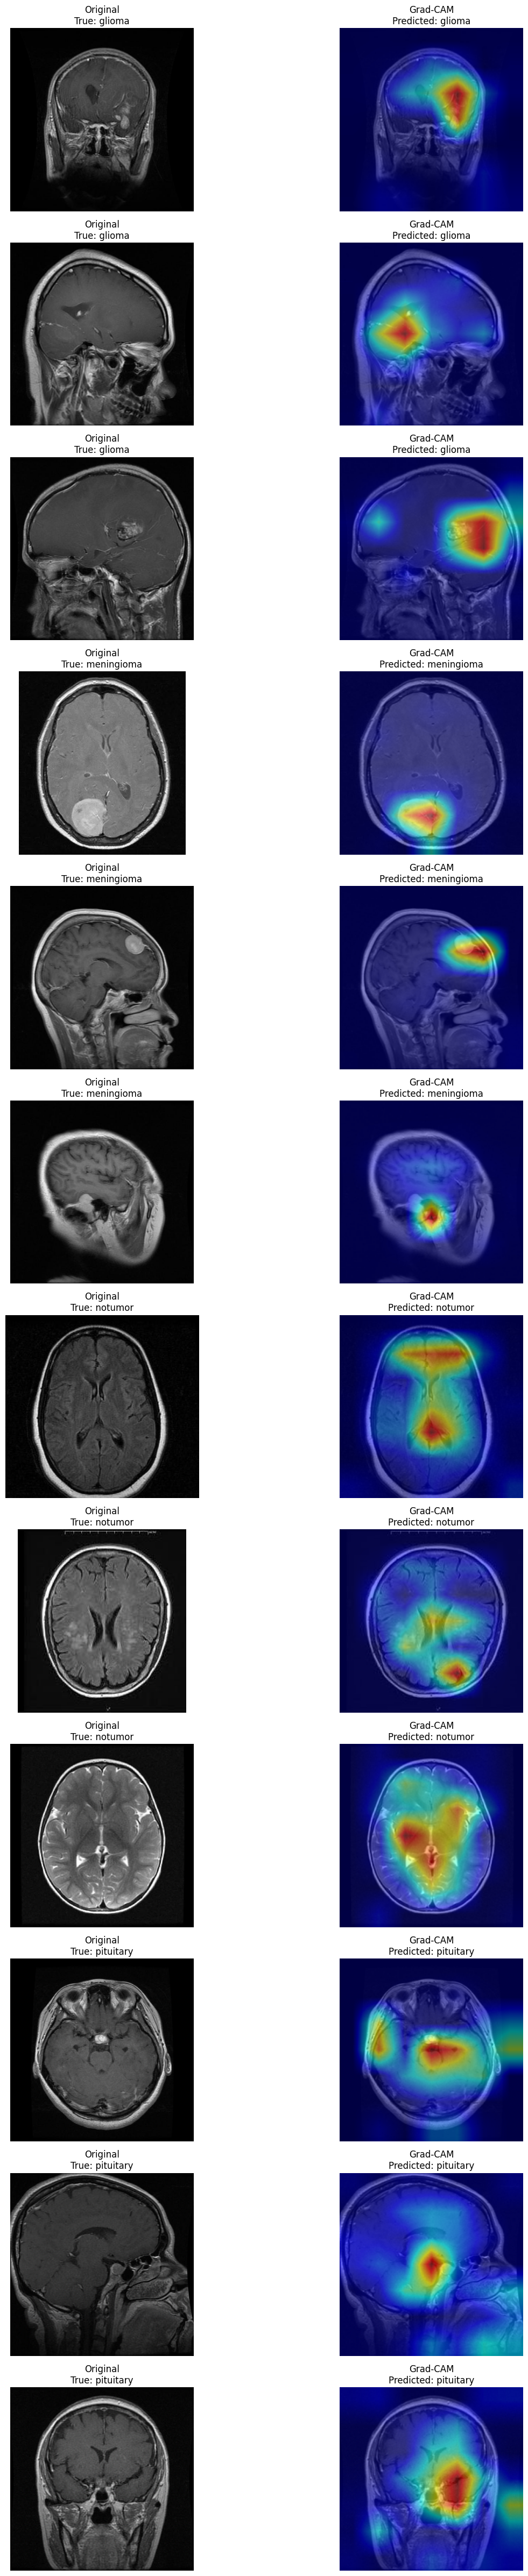

,image_path,true_class,predicted_class,gradcam_path
0,/kaggle/working/brain_tumor_yolov8/fixed_datas...,glioma,glioma,/kaggle/working/brain_tumor_yolov8/gradcam/01_...
1,/kaggle/working/brain_tumor_yolov8/fixed_datas...,glioma,glioma,/kaggle/working/brain_tumor_yolov8/gradcam/02_...
2,/kaggle/working/brain_tumor_yolov8/fixed_datas...,glioma,glioma,/kaggle/working/brain_tumor_yolov8/gradcam/03_...
3,/kaggle/working/brain_tumor_yolov8/fixed_datas...,meningioma,meningioma,/kaggle/working/brain_tumor_yolov8/gradcam/04_...
4,/kaggle/working/brain_tumor_yolov8/fixed_datas...,meningioma,meningioma,/kaggle/working/brain_tumor_yolov8/gradcam/05_...
5,/kaggle/working/brain_tumor_yolov8/fixed_datas...,meningioma,meningioma,/kaggle/working/brain_tumor_yolov8/gradcam/06_...
6,/kaggle/working/brain_tumor_yolov8/fixed_datas...,notumor,notumor,/kaggle/working/brain_tumor_yolov8/gradcam/07_...
7,/kaggle/working/brain_tumor_yolov8/fixed_datas...,notumor,notumor,/kaggle/working/brain_tumor_yolov8/gradcam/08_...
8,/kaggle/working/brain_tumor_yolov8/fixed_datas...,notumor,notumor,/kaggle/working/brain_tumor_yolov8/gradcam/09_...
9,/kaggle/working/brain_tumor_yolov8/fixed_datas...,pituitary,pituitary,/kaggle/working/brain_tumor_yolov8/gradcam/10_...


Grad-CAM images saved in: /kaggle/working/brain_tumor_yolov8/gradcam
Grad-CAM grid saved at: /kaggle/working/brain_tumor_yolov8/gradcam/mri_seed42_gradcam_grid.png
Grad-CAM records saved at: /kaggle/working/brain_tumor_yolov8/results/gradcam_visualization_records.csv


In [31]:
# =========================
# CELL 25 — GENERATE GRAD-CAM VISUALIZATIONS
# =========================

from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


GRADCAM_SAMPLES_PER_CLASS = 3

selected_gradcam_samples = []

for class_name in CLASS_NAMES:
    class_samples = best_test_predictions[
        best_test_predictions["true_class"] == class_name
    ].copy()

    correctly_classified = class_samples[
        class_samples["true_class"]
        == class_samples["predicted_class"]
    ]

    if len(correctly_classified) >= GRADCAM_SAMPLES_PER_CLASS:
        selected_samples = correctly_classified.sample(
            n=GRADCAM_SAMPLES_PER_CLASS,
            random_state=123,
        )
    else:
        selected_samples = class_samples.sample(
            n=min(
                GRADCAM_SAMPLES_PER_CLASS,
                len(class_samples),
            ),
            random_state=123,
        )

    selected_gradcam_samples.append(selected_samples)


selected_gradcam_df = pd.concat(
    selected_gradcam_samples,
    ignore_index=True,
)

gradcam_records = []


for sample_index, sample_row in selected_gradcam_df.iterrows():
    image_path = Path(sample_row["image_path"])

    true_class = sample_row["true_class"]
    predicted_class = sample_row["predicted_class"]
    predicted_index = int(sample_row["predicted_index"])

    pil_image = Image.open(image_path).convert("RGB")

    resized_image = pil_image.resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    rgb_image = (
        np.asarray(resized_image)
        .astype(np.float32)
        / 255.0
    )

    input_tensor = gradcam_transform(
        pil_image
    ).unsqueeze(0).to(DEVICE)

    targets = [
        ClassifierOutputTarget(
            predicted_index
        )
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets,
    )[0]

    gradcam_visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True,
    )

    output_filename = (
        f"{sample_index + 1:02d}_"
        f"true_{true_class}_"
        f"pred_{predicted_class}.png"
    )

    output_path = GRADCAM_DIR / output_filename

    Image.fromarray(
        gradcam_visualization
    ).save(output_path)

    gradcam_records.append({
        "image_path": str(image_path),
        "true_class": true_class,
        "predicted_class": predicted_class,
        "gradcam_path": str(output_path),
    })


gradcam_records_df = pd.DataFrame(
    gradcam_records
)

gradcam_records_path = (
    RESULTS_DIR
    / "gradcam_visualization_records.csv"
)

gradcam_records_df.to_csv(
    gradcam_records_path,
    index=False,
)


number_of_samples = len(gradcam_records_df)

plt.figure(
    figsize=(15, 4 * number_of_samples)
)

for index, record in gradcam_records_df.iterrows():
    original_image = Image.open(
        record["image_path"]
    ).convert("RGB")

    gradcam_image = Image.open(
        record["gradcam_path"]
    ).convert("RGB")

    plt.subplot(
        number_of_samples,
        2,
        (index * 2) + 1,
    )

    plt.imshow(original_image)
    plt.title(
        f"Original\nTrue: {record['true_class']}"
    )
    plt.axis("off")

    plt.subplot(
        number_of_samples,
        2,
        (index * 2) + 2,
    )

    plt.imshow(gradcam_image)
    plt.title(
        f"Grad-CAM\nPredicted: {record['predicted_class']}"
    )
    plt.axis("off")


plt.tight_layout()

gradcam_grid_path = (
    GRADCAM_DIR
    / f"{BEST_RUN_NAME}_gradcam_grid.png"
)

plt.savefig(
    gradcam_grid_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


display(gradcam_records_df)

print("Grad-CAM images saved in:", GRADCAM_DIR)
print("Grad-CAM grid saved at:", gradcam_grid_path)
print("Grad-CAM records saved at:", gradcam_records_path)

In [ ]:
# =========================
# CELL 26 — FINAL SUMMARY AND EXPORT PACKAGE
# =========================

final_summary = metrics_df[
    metrics_df["run_name"] == BEST_RUN_NAME
].copy()

final_summary = final_summary[
    [
        "run_name",
        "split",
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "mcc",
        "macro_roc_auc",
        "macro_average_precision",
    ]
]

final_summary_path = (
    RESULTS_DIR
    / "final_best_model_results.csv"
)

final_summary.to_csv(
    final_summary_path,
    index=False,
)

display(final_summary)


archive_base_path = (
    Path("/kaggle/working")
    / "brain_tumor_yolov8_complete_results"
)

archive_path = shutil.make_archive(
    base_name=str(archive_base_path),
    format="zip",
    root_dir=str(OUTPUT_ROOT),
)

print("\nExperiment completed successfully.")
print("Best model:", BEST_RUN_NAME)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Final summary saved at:", final_summary_path)
print("Complete ZIP package created at:", archive_path)
print("\nDownload the ZIP file from the Kaggle Output section.")

,run_name,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,mcc,macro_roc_auc,macro_average_precision
8,mri_seed42,val,0.989286,0.989286,0.989276,0.989286,0.989279,0.985715,0.999408,0.998453
9,mri_seed42,test,0.948750,0.948750,0.952926,0.948750,0.947359,0.933771,0.990086,0.980679
